# Optimization

This notebook studies how derivatives help locate maximum and minimum values, why optimization matters in machine learning, and how derivative information guides iterative search methods.

## Video 1 — Derivatives and optimization

**Optimization** means finding an input where a function reaches a maximum or minimum value.

In machine learning, a model is evaluated using an **error**, **loss**, or **objective** function. This function assigns a number that measures how poorly the model fits the chosen goal. Training often means adjusting the model's parameters to make that number as small as possible.

Derivatives help because they describe which direction makes the objective increase or decrease.

### Searching for the coldest place on a sauna bench

Imagine sitting on a sauna bench with a thermometer:

1. At the initial position, the temperature is $85$ degrees Celsius.
2. Moving left produces a reading of $90$ degrees Celsius, so that direction is hotter.
3. Moving right produces a reading of $80$ degrees Celsius, so that direction is colder.
4. Continuing toward lower readings eventually reaches a position where moving either way makes the temperature rise.

That final position is a minimum of the temperature function: locally, no nearby position is colder.

### What the derivative says

Let $T(x)$ be the temperature at position $x$ along the bench.

- If $T'(x)<0$, the graph slopes downward as $x$ increases, so moving right decreases the temperature.
- If $T'(x)>0$, the graph slopes upward as $x$ increases, so moving left decreases the temperature.
- At a smooth interior minimum, $T'(x)=0$ because the tangent is horizontal.

Thus, points satisfying

$$
T'(x)=0
$$

are **candidates** for maxima or minima. A zero derivative alone does not prove that a point is an optimum.

### Simple and more complicated temperature curves

The left plot reconstructs the lecture's $85$, $90$, and $80$ degree readings using schematic bench positions. The curve and its minimum temperature are illustrative because their exact values are not supplied in the transcript.

The right plot is also schematic. It shows why a complicated function may have several zero-derivative candidates that must be classified.

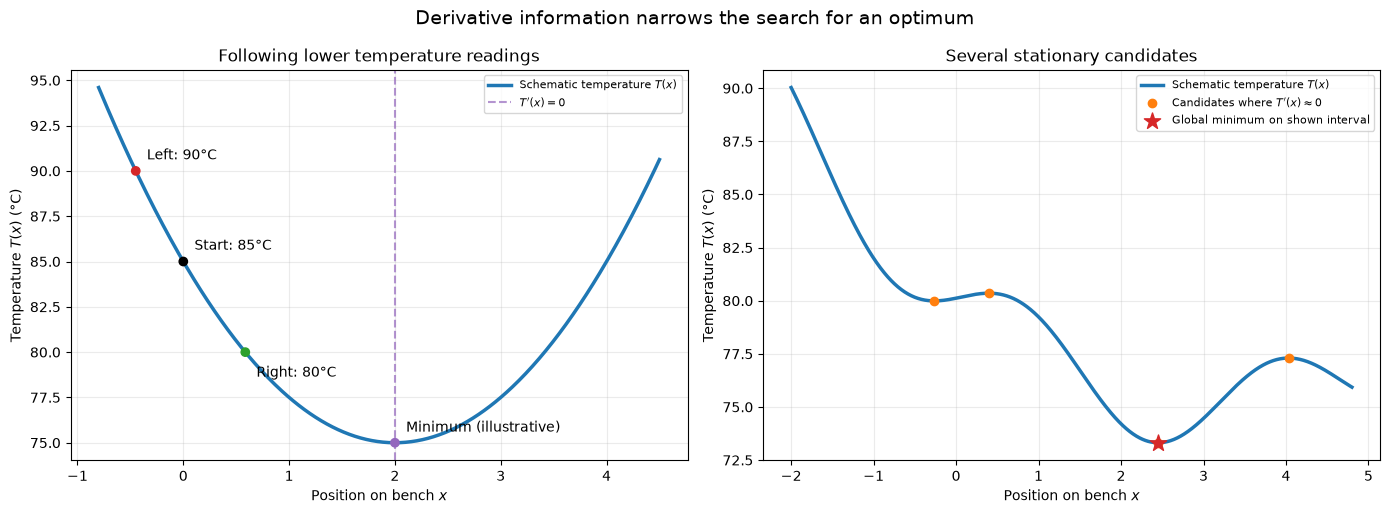

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np

simple_positions: np.ndarray = np.linspace(-0.8, 4.5, 500)
simple_temperatures: np.ndarray = 75.0 + 2.5 * (simple_positions - 2.0) ** 2
initial_position: float = 0.0
left_trial_position: float = 2.0 - float(np.sqrt(6.0))
right_trial_position: float = 2.0 - float(np.sqrt(2.0))
minimum_position: float = 2.0

complex_positions: np.ndarray = np.linspace(-2.0, 4.8, 1000)
complex_temperatures: np.ndarray = (
    75.0 + 0.5 * (complex_positions - 3.2) ** 2 + 2.0 * np.sin(2.0 * complex_positions)
)
complex_derivatives: np.ndarray = complex_positions - 3.2 + 4.0 * np.cos(2.0 * complex_positions)
critical_indices: np.ndarray = np.flatnonzero(
    np.sign(complex_derivatives[:-1]) != np.sign(complex_derivatives[1:])
)
global_minimum_index: int = int(np.argmin(complex_temperatures))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
axes[0].plot(simple_positions, simple_temperatures, color="tab:blue", linewidth=2.5,
             label="Schematic temperature $T(x)$")
axes[0].scatter(
    [initial_position, left_trial_position, right_trial_position, minimum_position],
    [85.0, 90.0, 80.0, 75.0],
    color=["black", "tab:red", "tab:green", "tab:purple"],
    zorder=3,
)
axes[0].annotate("Start: $85°$C", (initial_position, 85.0), xytext=(8, 8),
                 textcoords="offset points")
axes[0].annotate("Left: $90°$C", (left_trial_position, 90.0), xytext=(8, 8),
                 textcoords="offset points")
axes[0].annotate("Right: $80°$C", (right_trial_position, 80.0), xytext=(8, -18),
                 textcoords="offset points")
axes[0].annotate("Minimum (illustrative)", (minimum_position, 75.0), xytext=(8, 8),
                 textcoords="offset points")
axes[0].axvline(minimum_position, color="tab:purple", linestyle="--", alpha=0.7,
                label="$T'(x)=0$")
axes[0].set(title="Following lower temperature readings", xlabel="Position on bench $x$",
            ylabel="Temperature $T(x)$ (°C)")
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=8)

axes[1].plot(complex_positions, complex_temperatures, color="tab:blue", linewidth=2.5,
             label="Schematic temperature $T(x)$")
axes[1].scatter(complex_positions[critical_indices], complex_temperatures[critical_indices],
                color="tab:orange", zorder=3, label="Candidates where $T'(x)\\approx0$")
axes[1].scatter([complex_positions[global_minimum_index]],
                [complex_temperatures[global_minimum_index]], color="tab:red", marker="*",
                s=150, zorder=4, label="Global minimum on shown interval")
axes[1].set(title="Several stationary candidates", xlabel="Position on bench $x$",
            ylabel="Temperature $T(x)$ (°C)")
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=8)

fig.suptitle("Derivative information narrows the search for an optimum", fontsize=14)
fig.tight_layout()
plt.show()

### Local and global minima

A **local minimum** is a point whose function value is no larger than the values at nearby points. A **global minimum** is a point whose function value is no larger than the value at every other point in the domain.

A complicated function can contain several stationary points where

$$
f'(x)=0.
$$

They are candidates, not guaranteed minima. A stationary point could be:

- a local minimum;
- a local maximum;
- neither, such as a flat point where the function continues increasing.

To find the global minimum, the candidates must be evaluated and compared with every other type of candidate required by the domain.

### The condition behind the zero-slope rule

The precise result is:

> If $f$ is differentiable at an **interior** point $x^*$ and has a local maximum or minimum there, then $f'(x^*)=0$.

The conditions matter. An optimum can also occur:

- at an endpoint of a restricted interval;
- at a point where the derivative does not exist, such as the corner of $|x|$;
- at one of several points where the derivative is zero.

Therefore, solving $f'(x)=0$ finds important candidates, but it does not complete every optimization problem by itself.

### Takeaway

Derivatives turn optimization into a more focused search:

$$
\boxed{f'(x)=0}
$$

identifies stationary candidates for smooth interior maxima and minima. The derivative's sign also provides direction:

- $f'(x)<0$: increasing $x$ locally decreases $f$;
- $f'(x)>0$: decreasing $x$ locally decreases $f$;
- $f'(x)=0$: inspect and classify the point.

In machine learning, this idea is used to search for parameter values that minimize a chosen loss or objective function.

## Video 2 — Minimizing a squared connection cost

Consider choosing where to build a house that must connect to several power lines. Longer connections require more cable and are modeled as more expensive.

In this simplified problem, the cost of one connection is the square of its distance:

$$
\text{connection cost}=(\text{distance})^2.
$$

The goal is to place the house where the **total** cost of all connections is as small as possible.

### Why squared cost matters in machine learning

This connection cost has the same mathematical shape as **squared error**:

$$
\text{squared error}=(\text{prediction}-\text{target})^2.
$$

The difference between a prediction and its target is called the **error** or **residual**. Squaring it makes the result nonnegative and penalizes larger errors more strongly.

Squared error is commonly used to train linear regression models and also appears in some neural-network objectives. Learning to minimize a squared distance therefore prepares us to minimize machine-learning loss functions.

### Start with one power line

Let

- $x$ be the house's position along a one-dimensional coordinate line;
- $p$ be the power line's position.

The distance between them is $|x-p|$. Squaring removes the absolute value because

$$
|x-p|^2=(x-p)^2.
$$

Therefore, the connection cost is

$$
C(x)=(x-p)^2.
$$

If the power line is used as the origin, then $p=0$ and this becomes the transcript's simpler formula:

$$
C(x)=x^2.
$$

### The minimum occurs at the power line

Differentiate the cost:

$$
C'(x)=2(x-p).
$$

A smooth interior minimum must be among the points where the derivative is zero:

$$
\begin{aligned}
2(x-p)&=0, \\
x-p&=0, \\
x&=p.
\end{aligned}
$$

At this position, the distance and cost are both zero:

$$
C(p)=(p-p)^2=0.
$$

Because a square can never be negative, zero is the global minimum. With one power line, the least expensive location is directly beside that line.

### Visualizing the one-line cost

The power-line coordinate below is illustrative because the transcript does not assign it a numerical position. The horizontal distance from $x$ to $p$ becomes the height $(x-p)^2$ on the cost curve.

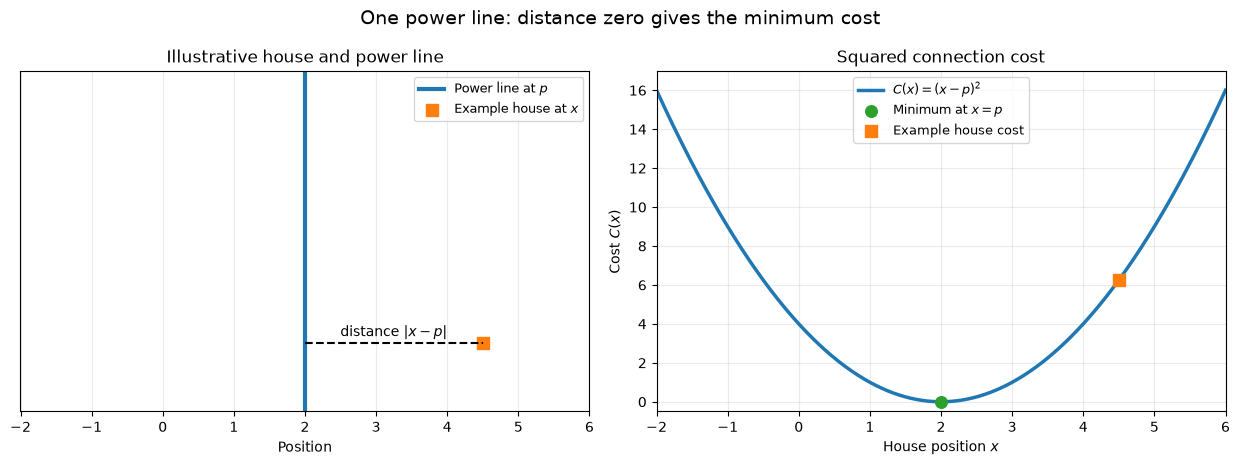

In [2]:
power_line_position: float = 2.0
house_positions: np.ndarray = np.linspace(-2.0, 6.0, 400)
connection_costs: np.ndarray = (house_positions - power_line_position) ** 2
example_house_position: float = 4.5
example_connection_cost: float = (example_house_position - power_line_position) ** 2

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.7))

axes[0].axvline(power_line_position, color="tab:blue", linewidth=3, label="Power line at $p$")
axes[0].scatter([example_house_position], [0], color="tab:orange", marker="s", s=75,
                label="Example house at $x$")
axes[0].annotate(
    "distance $|x-p|$",
    xy=((power_line_position + example_house_position) / 2, 0.03),
    ha="center",
)
axes[0].plot([power_line_position, example_house_position], [0, 0], color="black",
             linestyle="--")
axes[0].set(title="Illustrative house and power line", xlabel="Position", ylabel="",
            xlim=(-2, 6), ylim=(-0.3, 1.2), yticks=[])
axes[0].grid(axis="x", alpha=0.25)
axes[0].legend(fontsize=9)

axes[1].plot(house_positions, connection_costs, color="tab:blue", linewidth=2.5,
             label="$C(x)=(x-p)^2$")
axes[1].scatter([power_line_position], [0], color="tab:green", s=70, zorder=3,
                label="Minimum at $x=p$")
axes[1].scatter([example_house_position], [example_connection_cost], color="tab:orange",
                marker="s", s=65, zorder=3, label="Example house cost")
axes[1].set(title="Squared connection cost", xlabel="House position $x$",
            ylabel="Cost $C(x)$", xlim=(-2, 6), ylim=(-0.5, 17))
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=9)

fig.suptitle("One power line: distance zero gives the minimum cost", fontsize=14)
fig.tight_layout()
plt.show()

### Setting up the multi-line problem

If three power lines lie at positions $p_1$, $p_2$, and $p_3$, then the total squared connection cost is

$$
C(x)
=
(x-p_1)^2+(x-p_2)^2+(x-p_3)^2.
$$

Each line contributes one squared-distance term. This has the same sum-of-squares structure as a machine-learning objective with several data points.

The next step is to differentiate this total cost and determine which house position minimizes it.

## Video 3 — Optimizing the location between two power lines

Place two power lines on a one-dimensional coordinate line:

- the blue power line is at position $a$;
- the orange power line is at position $b$;
- the house is at position $x$.

Assume $a<b$. When the house lies between the lines, its distances are

$$
x-a
\qquad\text{and}\qquad
b-x.
$$

The goal is to choose $x$ so that the total squared connection cost is as small as possible.

### Squaring removes the direction

The blue connection costs

$$
(x-a)^2,
$$

and the orange connection costs

$$
(b-x)^2.
$$

Because $b-x=-(x-b)$ and squaring removes the sign,

$$
(b-x)^2=(x-b)^2.
$$

We can therefore write every squared distance in the consistent form $(x-\text{line position})^2$, even if the difference inside the parentheses is negative.

The total cost is

$$
\boxed{C(x)=(x-a)^2+(x-b)^2.}
$$

### Squared distances as square areas

A square with side length $|x-a|$ has area $(x-a)^2$, and a square with side length $|x-b|$ has area $(x-b)^2$. The total connection cost can therefore be visualized as the sum of these two square areas.

Moving too far left makes the orange square large. Moving too far right makes the blue square large. The balance occurs halfway between the power lines.

The following diagram uses illustrative positions $a=1$ and $b=7$ because the transcript supplies symbols but no numerical coordinates.

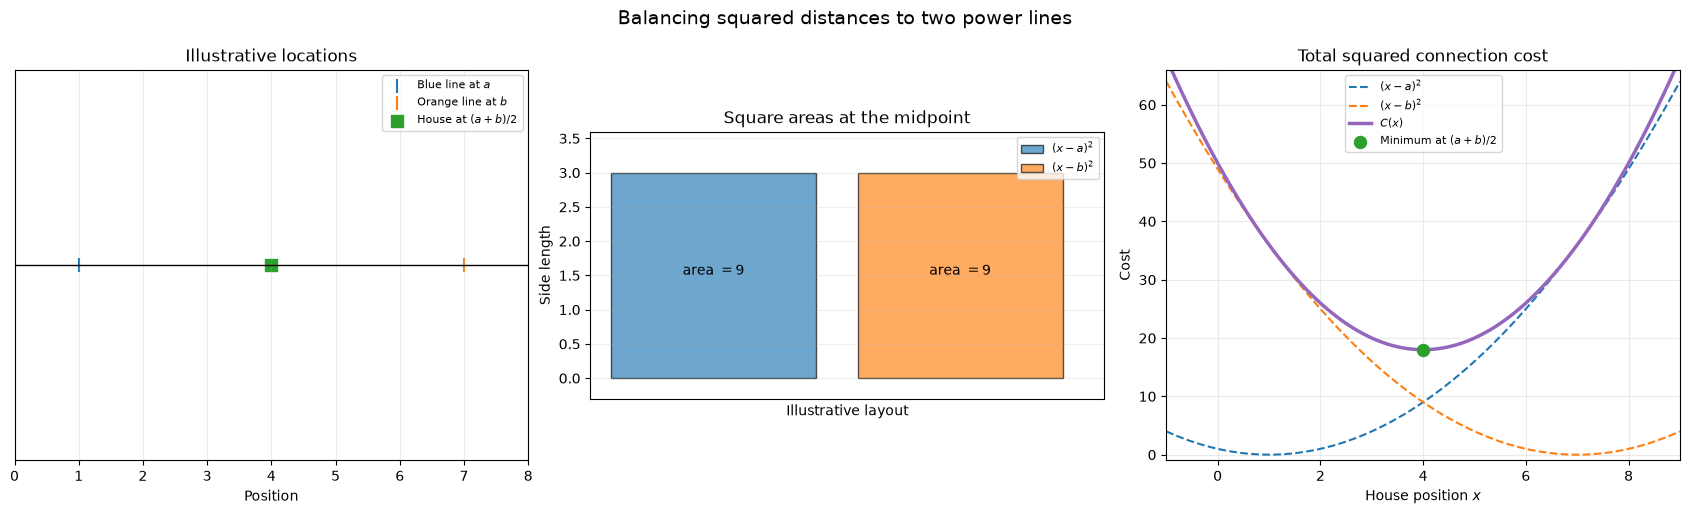

In [3]:
from matplotlib.patches import Rectangle

two_line_a: float = 1.0
two_line_b: float = 7.0
two_line_midpoint: float = (two_line_a + two_line_b) / 2.0
two_line_distance: float = two_line_midpoint - two_line_a
two_line_positions: np.ndarray = np.linspace(-1.0, 9.0, 500)
blue_costs: np.ndarray = (two_line_positions - two_line_a) ** 2
orange_costs: np.ndarray = (two_line_positions - two_line_b) ** 2
total_two_line_costs: np.ndarray = blue_costs + orange_costs
minimum_two_line_cost: float = 2.0 * two_line_distance**2

fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))

axes[0].axhline(0, color="black", linewidth=1)
axes[0].scatter([two_line_a], [0], color="tab:blue", s=100, marker="|",
                label="Blue line at $a$")
axes[0].scatter([two_line_b], [0], color="tab:orange", s=100, marker="|",
                label="Orange line at $b$")
axes[0].scatter([two_line_midpoint], [0], color="tab:green", s=85, marker="s",
                label="House at $(a+b)/2$")
axes[0].set(title="Illustrative locations", xlabel="Position", ylabel="", xlim=(0, 8),
            ylim=(-0.8, 0.8), yticks=[])
axes[0].grid(axis="x", alpha=0.25)
axes[0].legend(fontsize=8)

blue_square = Rectangle((0, 0), two_line_distance, two_line_distance,
                        facecolor="tab:blue", alpha=0.65, edgecolor="black",
                        label="$(x-a)^2$")
orange_square = Rectangle((two_line_distance + 0.6, 0), two_line_distance, two_line_distance,
                          facecolor="tab:orange", alpha=0.65, edgecolor="black",
                          label="$(x-b)^2$")
axes[1].add_patch(blue_square)
axes[1].add_patch(orange_square)
axes[1].annotate(rf"area $={two_line_distance**2:g}$", (1.5, 1.5), ha="center")
axes[1].annotate(rf"area $={two_line_distance**2:g}$", (5.1, 1.5), ha="center")
axes[1].set(
    title="Square areas at the midpoint",
    xlabel="Illustrative layout",
    ylabel="Side length",
    xlim=(-0.3, 7.2),
    ylim=(-0.3, 3.6),
    xticks=[],
)
axes[1].set_aspect("equal")
axes[1].grid(alpha=0.2)
axes[1].legend(fontsize=8)

axes[2].plot(two_line_positions, blue_costs, color="tab:blue", linestyle="--",
             label="$(x-a)^2$")
axes[2].plot(two_line_positions, orange_costs, color="tab:orange", linestyle="--",
             label="$(x-b)^2$")
axes[2].plot(two_line_positions, total_two_line_costs, color="tab:purple", linewidth=2.5,
             label="$C(x)$")
axes[2].scatter([two_line_midpoint], [minimum_two_line_cost], color="tab:green", s=75,
                zorder=3, label="Minimum at $(a+b)/2$")
axes[2].set(title="Total squared connection cost", xlabel="House position $x$",
            ylabel="Cost", xlim=(-1, 9), ylim=(-1, 66))
axes[2].grid(alpha=0.25)
axes[2].legend(fontsize=8)

fig.suptitle("Balancing squared distances to two power lines", fontsize=14)
fig.tight_layout()
plt.show()

### Why the cost curve opens upward

Expand both squares:

$$
\begin{aligned}
C(x)
&=(x-a)^2+(x-b)^2 \\
&=(x^2-2ax+a^2)+(x^2-2bx+b^2) \\
&=2x^2-2(a+b)x+a^2+b^2.
\end{aligned}
$$

The coefficient of $x^2$ is $2$, which is positive. Therefore, the graph is an upward-opening parabola, and its horizontal-tangent point is its global minimum.

### Differentiate and solve

Differentiate the cost and set the result equal to zero. The chain rule makes the inner derivative explicit:

$$
\begin{aligned}
C'(x)
&=2(x-a)\frac{d}{dx}(x-a)
 +2(x-b)\frac{d}{dx}(x-b) \\
&=2(x-a)(1)+2(x-b)(1) \\
&=2(x-a)+2(x-b).
\end{aligned}
$$

Now solve $C'(x)=0$:

$$
\begin{aligned}
2(x-a)+2(x-b)&=0, \\
(x-a)+(x-b)&=0, \\
2x-a-b&=0, \\
2x&=a+b, \\
x&=\frac{a+b}{2}.
\end{aligned}
$$

### Takeaway

The least-cost house position is

$$
\boxed{x=\frac{a+b}{2}.}
$$

This is exactly the midpoint of the two power lines. At the midpoint, the two distances are equal, so neither squared-distance term dominates the other.

The same strategy extends to more power lines:

1. add one squared-distance term for each line;
2. differentiate the total cost;
3. set the derivative equal to zero;
4. solve for the minimizing location.